In [2]:
from src.configmanager.experimentconfigmanager import *

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [80]:
global_hparams = {
    "lr"                : 0.00005,
    "n_epochs"          : 1,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.75, 'patience': 6, 'min_lr': 1e-8},
    'min_delta'         : 0,
    'loss'              : 'outbreakweighted',
    'loss_kwargs'       : {'outbreak_threshold': 0 , 'outbreak_weight': 5},
    'patience'          : 20,
    }


train_hparams = {'verbose':2 , 
                 'dataloader_snapshot': False, 
                 'show_loss' : False}

config = ExperimentConfig(
    name='measles_gatv2',
    data=DataConfig(
        disease_name    = 'measles',
        nuts_level      = 'nuts3',
        min_date        = '2006-05-15',
        max_date        = '2020-06-01',
        split_berlin    = False,
        include_population= False

    ),
    timeseries=TimeSeriesConfig(
        horizon_size    = 1,
        horizon_leadtime= 1,
        sequence_length = 1,
        lags            = 1
    ),
    preprocessing=PreprocessingConfig(
        log_transform_target= False,
        add_time_features   = True,
        normalization_method='zscore'
    ),
    splits=SplitConfig(
        split_trainval  = '2017-06-01',
        split_valtest   = '2018-06-01',
    ),
    model= ['GATv2Model'],
    global_hparams = global_hparams,
    train_hparams  = train_hparams,
    model_hparams  = {'self_loops': True},
    # graphs         = ['gravity1','gravity2','gravity3','gravity4','commuter1','commuter2','commuter3','commuter4','identity_graph','boolean_neighbors_self'],
    graphs = ['identity_graph'],
    baseline = True
)
runner = ExperimentRunner()
evaluator = runner.define(config).execute('measles_gatv2')

interesting_nodes = [26,391, 69, 30]

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-05-01 (+2 weeks)
berlin districts removed

== Training GATv2Model_identity_graph ==


Forecasting test: 100%|████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 412.80it/s]

Test loss: 1.3712


<DeepDataLoader(disease=measles, nuts_level=nuts3, min_date=2006-05-01, max_date=2020-06-01, horizon_size=1, horizon_leadtime=1, sequence_length=1)>

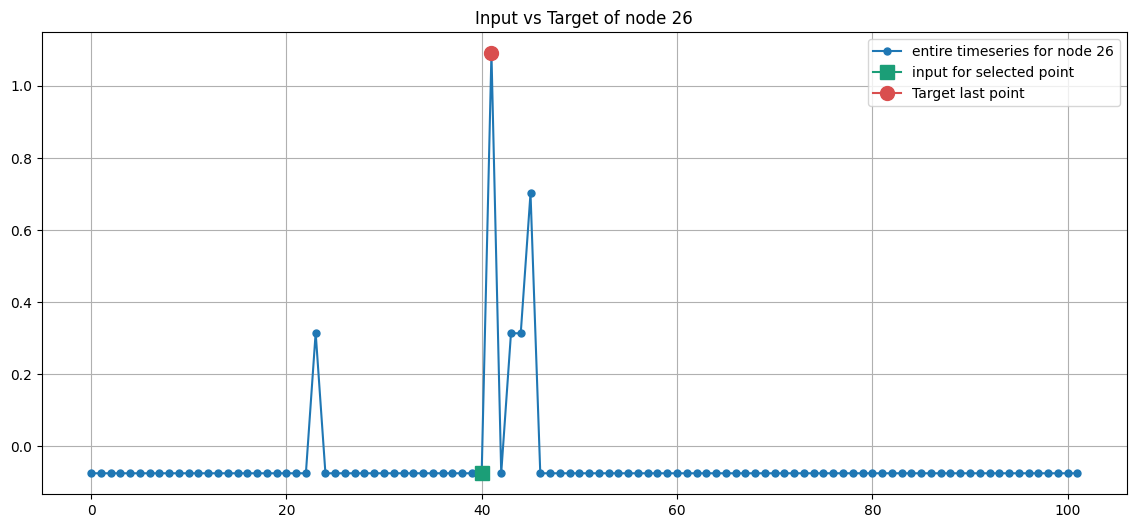

In [66]:
runner.models_dict['GATv2Model_commuter1'].dataloader.preview_dataloader(26, 41)

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:25<00:00,  4.33s/it]
/home/de-schrijvers/projects/germany_gnn/src/evaluation/plotter.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


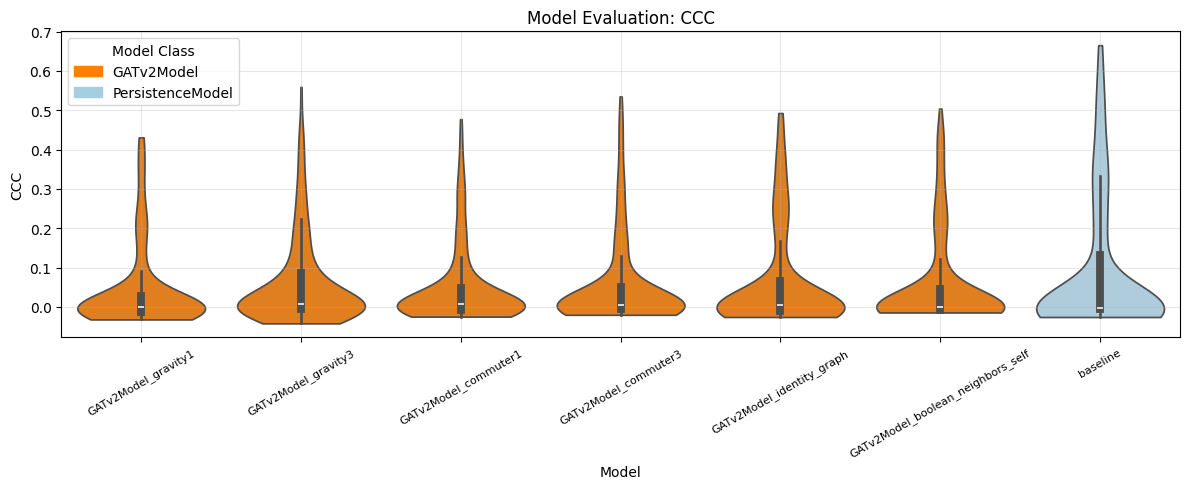

In [119]:
evaluator.add_evaluation()
evaluator.plotter.plot_metric('ccc',plot_type = 'violin')
# evaluator.plotter.plot_metric('ccc',plot_type = 'map')


/home/de-schrijvers/projects/germany_gnn/src/evaluation/plotter.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


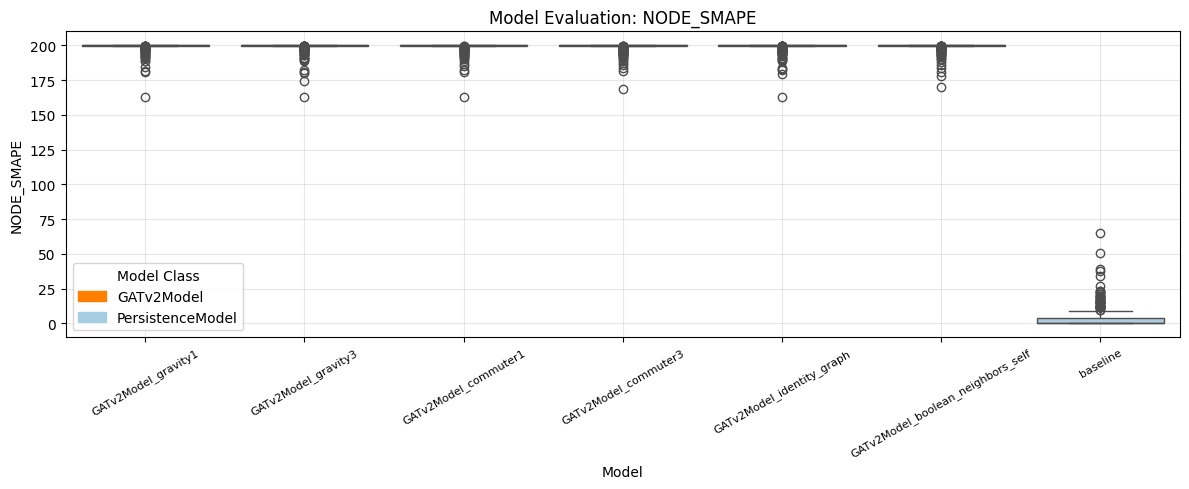

In [5]:
evaluator.plotter.plot_metric('node_smape', plot_type = 'box')

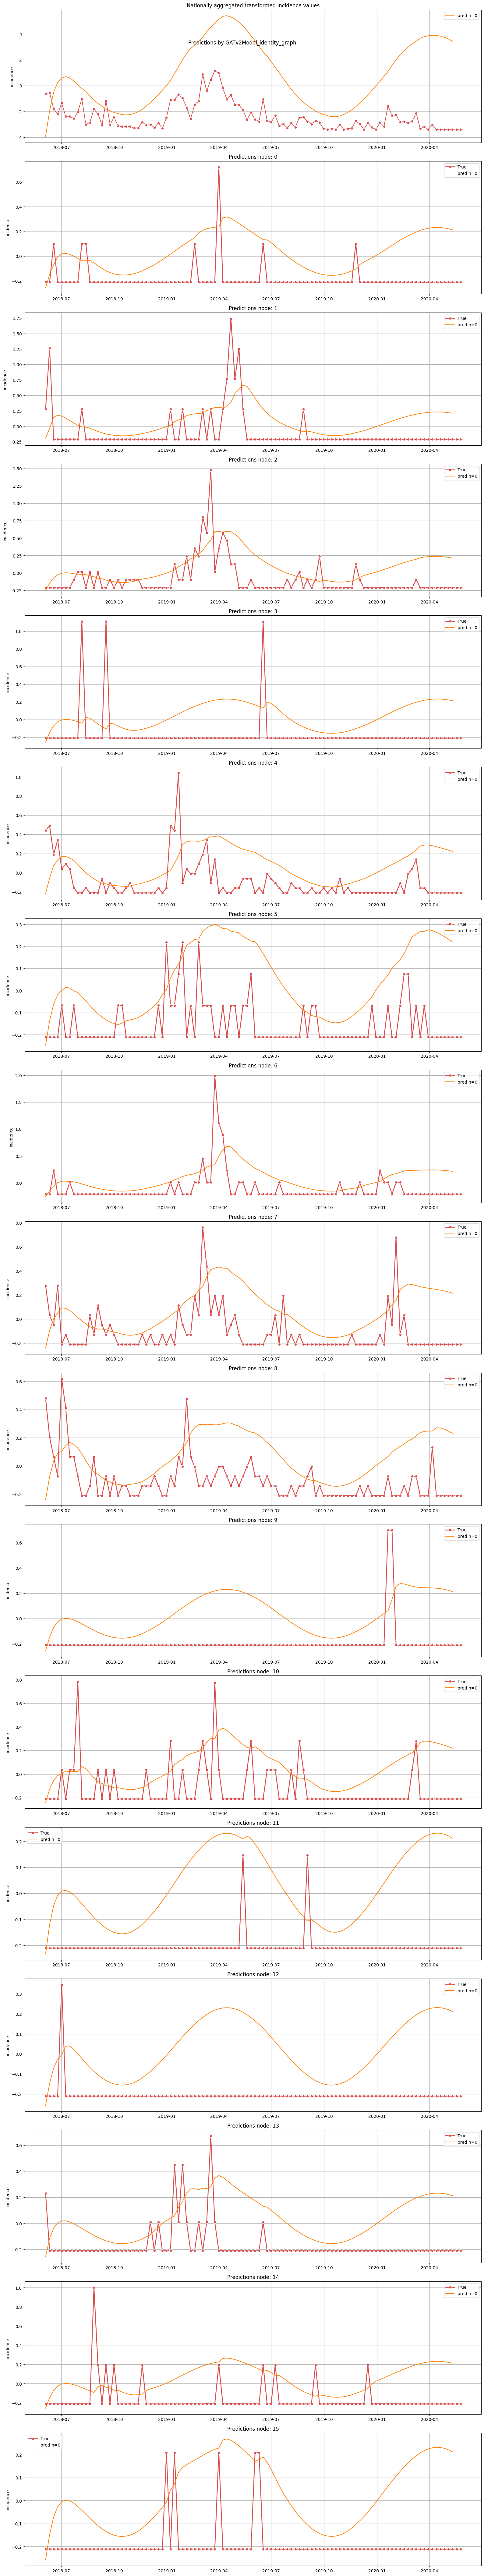

In [77]:
node = range(16)
ii   = 0
for ml in list(runner.models_dict.values()):
    if ii == 0:
        ml.show_forecasts('test',node, transformed = True)
    ii =+ 1

In [72]:
runner.models_dict['GATv2Model_identity_graph']

GATv2Model(name='GATv2Model_identity_graph')

In [81]:
from src .graphconstruction import GraphConstructor

graphs         = ['gravity1','gravity2','gravity3','gravity4','commuter1','commuter2','commuter3','commuter4','identity_graph','boolean_neighbors_self'],

graphconstruction = GraphConstructor(epidata = runner.models_dict['GATv2Model_identity_graph'].dataloader)

graphconstruction.generate_graph(
    method='identity', 
    self_connection='0'
    )

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    self_connection='max',
)

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    self_connection='0',
)
# long distance, sparse
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 3,
    alpha = 1,
    decay = 1,
    scaling_method='rowwise'
)

# long distance, dense
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 7,
    alpha = 1,
    decay = 1,
    scaling_method='rowwise',
    name_addition='2'
)

# more locally oriented, sparse
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 3,
    alpha = 2,
    decay = 1,
    scaling_method='rowwise',
    name_addition='3'
)


# more locally oriented, denser
graphconstruction.generate_graph(
    method='gravity_model', 
    self_connection='0',
    max_distance = 1000_000,
    top_k = 7,
    alpha = 2,
    decay = 1,
    scaling_method='rowwise',
    name_addition='4'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='0',
    commuter_type = 'static',
    commuting_threshold = 1000,
    top_k = 4,
    scaling_method='rowwise',
    name_addition='1'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='0',
    commuter_type = 'static',
    commuting_threshold = 1000,
    top_k = 4,
    scaling_method='rowwise',
    name_addition='2'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='0',
    commuter_type = 'static',
    commuting_threshold = 1000,
    scaling_method='rowwise',
    name_addition='3'
)

graphconstruction.generate_graph(
    method='commuter', 
    self_connection='0',
    commuter_type = 'static',
    commuting_threshold = 1000,
    scaling_method='rowwise',
    name_addition='4'
)

graphconstruction.rename_graph('identity_self0',                'identity_graph')
graphconstruction.rename_graph('boolean_neighbors_selfmax',     'boolean_neighbors_self')
graphconstruction.rename_graph('boolean_neighbors_self0',       'boolean_neighbors_nonself')
graphconstruction.rename_graph('gravity_model_self0_rowwise',   'gravity1')
graphconstruction.rename_graph('gravity_model_2_self0_rowwise', 'gravity2')
graphconstruction.rename_graph('gravity_model_3_self0_rowwise', 'gravity3')
graphconstruction.rename_graph('gravity_model_4_self0_rowwise', 'gravity4')
graphconstruction.rename_graph('commuter_1_self0_rowwise',      'commuter1')
graphconstruction.rename_graph('commuter_2_self0_rowwise',   'commuter2')
graphconstruction.rename_graph('commuter_3_self0_rowwise',      'commuter3')
graphconstruction.rename_graph('commuter_4_self0_rowwise',   'commuter4')


✓ graph generated: identity_self0
✓ graph generated: boolean_neighbors_selfmax
✓ graph generated: boolean_neighbors_self0
✓ graph generated: gravity_model_self0_rowwise
✓ graph generated: gravity_model_2_self0_rowwise
✓ graph generated: gravity_model_3_self0_rowwise
✓ graph generated: gravity_model_4_self0_rowwise
✓ graph generated: commuter_1_self0_rowwise
✓ graph generated: commuter_2_self0_rowwise
✓ graph generated: commuter_3_self0_rowwise
✓ graph generated: commuter_4_self0_rowwise
identity_self0 has been replaced by identity_graph
boolean_neighbors_selfmax has been replaced by boolean_neighbors_self
boolean_neighbors_self0 has been replaced by boolean_neighbors_nonself
gravity_model_self0_rowwise has been replaced by gravity1
gravity_model_2_self0_rowwise has been replaced by gravity2
gravity_model_3_self0_rowwise has been replaced by gravity3
gravity_model_4_self0_rowwise has been replaced by gravity4
commuter_1_self0_rowwise has been replaced by commuter1
commuter_2_self0_rowwi

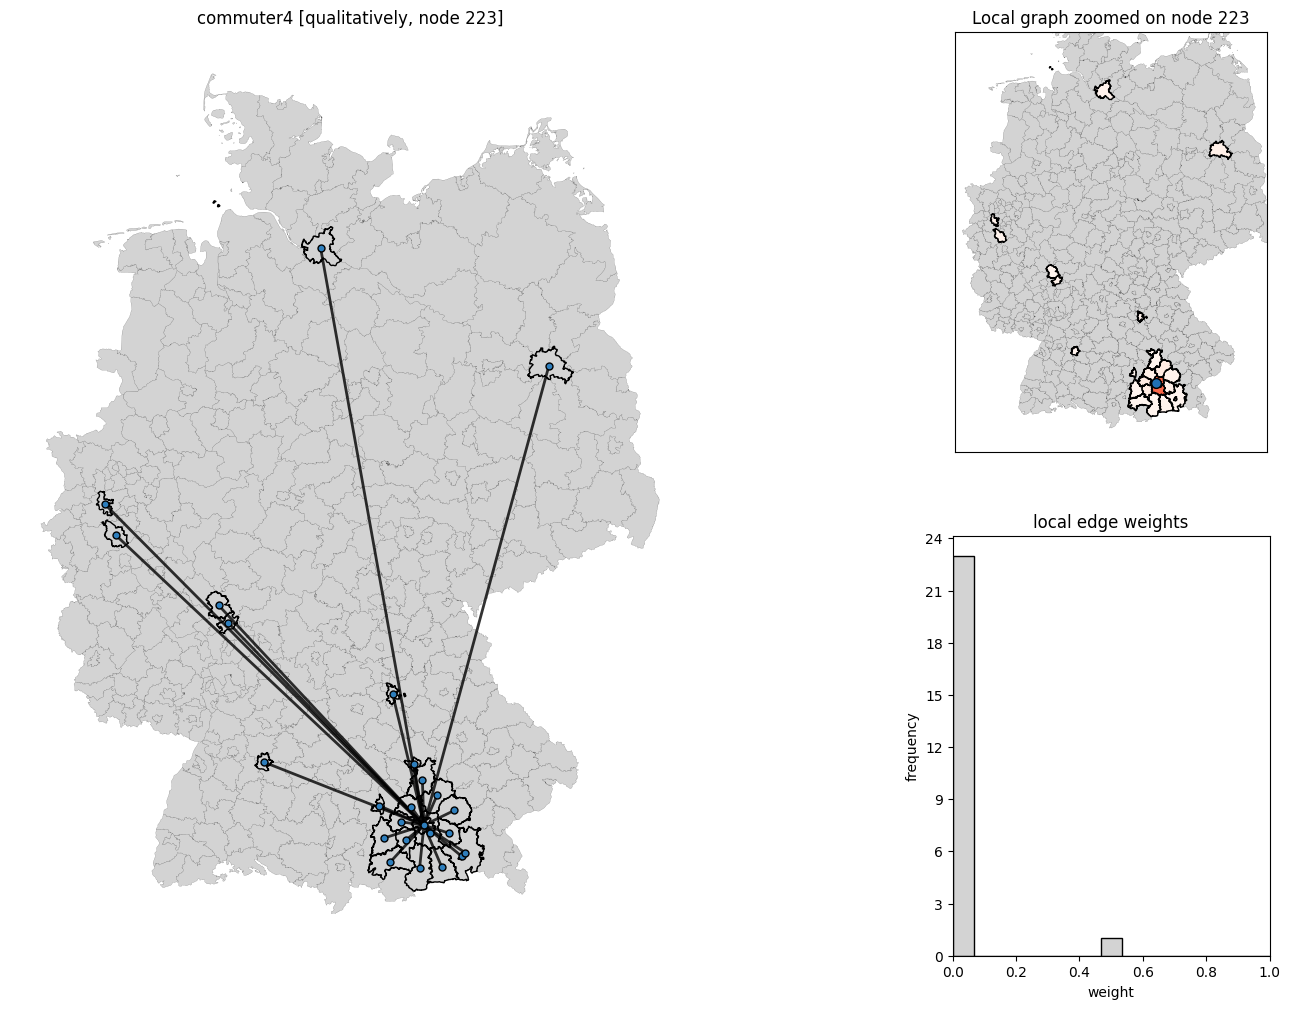

In [86]:
graphconstruction.preview_graph('commuter4',node_idx = 223)

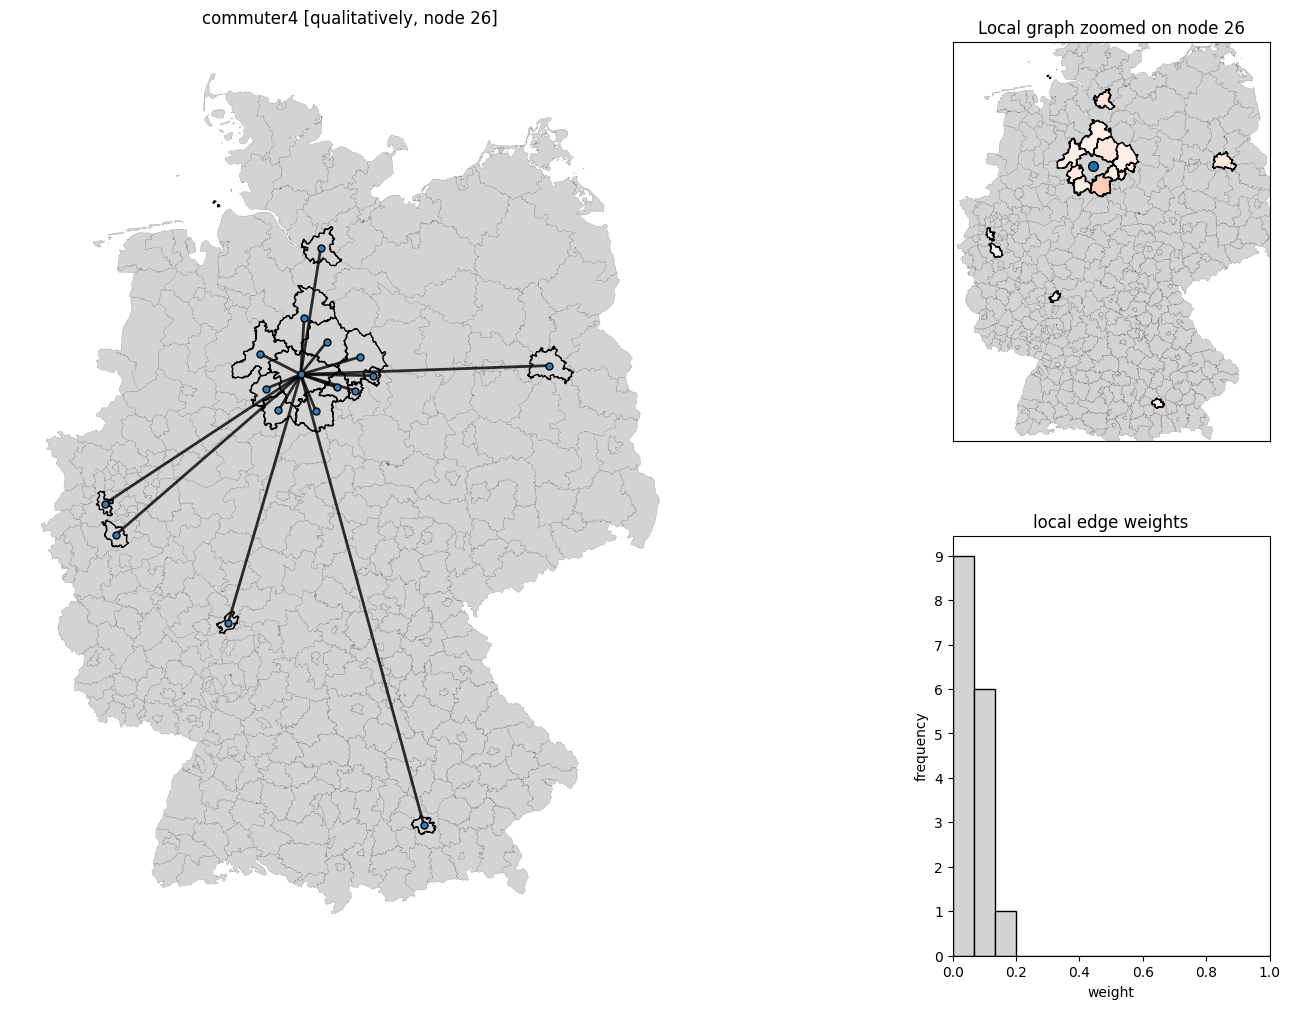

In [29]:
graphconstruction.preview_graph('commuter4',26)

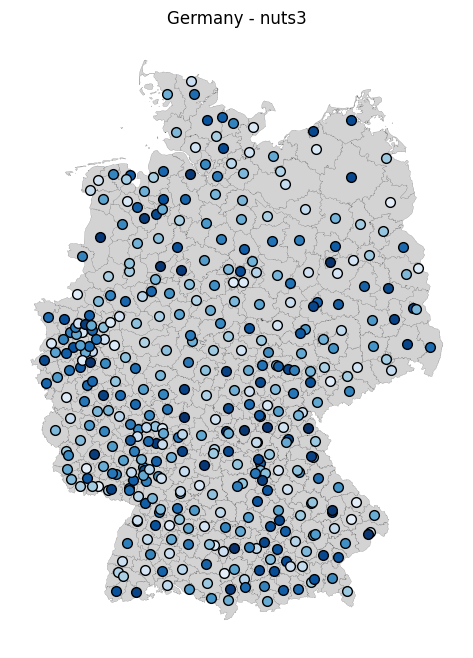

In [ ]:
graphconstruction.preview_graph('gravity1',26)

2024-04-29 00:00:00


Text(0.5, 1.0, 'predictions - commuter1')

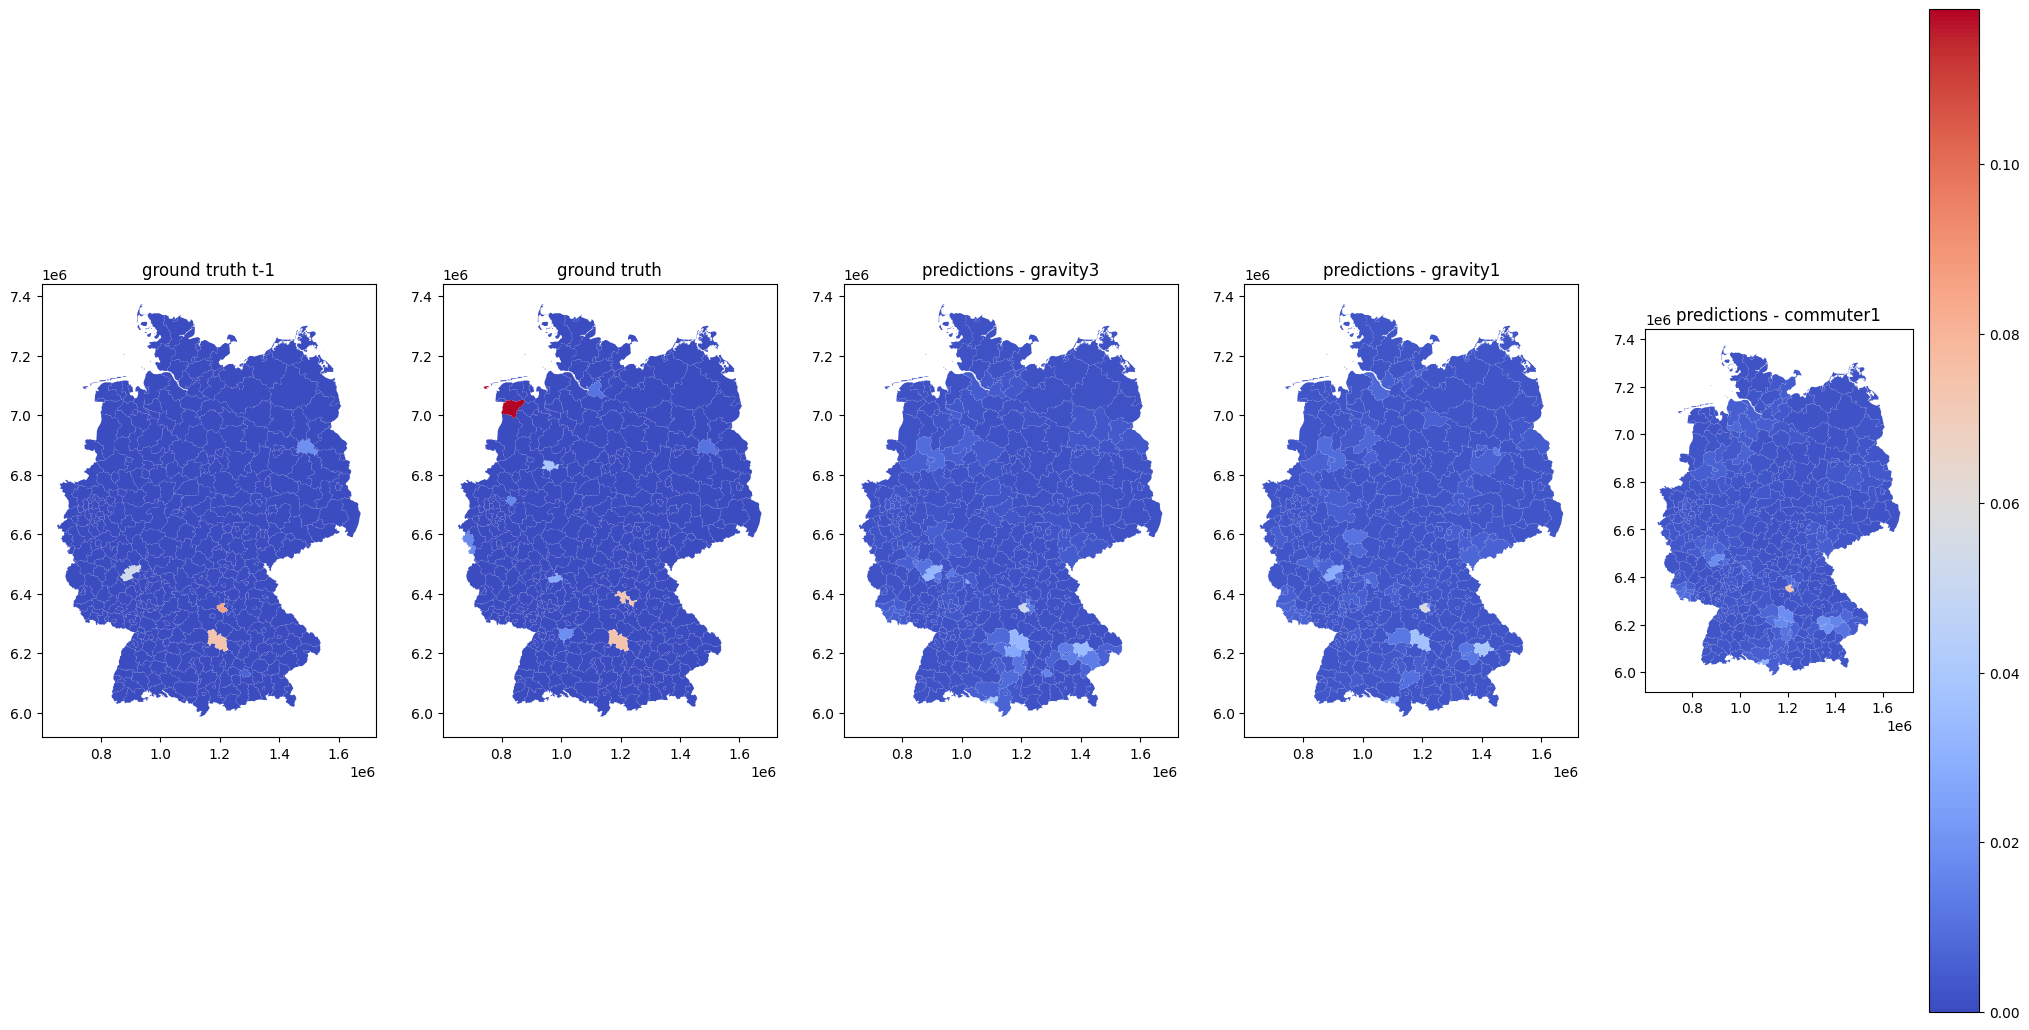

In [ ]:
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt

timestep_idx =225
unique_timesteps = evaluator.evaluation_compilations['horizon_0'].copy()['timestamp'].unique()
timestep = unique_timesteps[timestep_idx]

cp = evaluator.evaluation_compilations['horizon_0'].copy()

minvalue = 0.006
cp.set_index(['timestamp','node'], inplace= True) 

shapedata = runner.models_dict['GATv2Model_boolean_neighbors_self'].dataloader.data['context']['shapedata']

print(timestep)

cp_cp = cp.copy().reset_index(drop = False)
cp_cp_neg1 = cp_cp[cp_cp['timestamp'] == unique_timesteps[timestep_idx-1]]
cp_cp = cp_cp[cp_cp['timestamp'] == timestep]

fig, axes = plt.subplots(1, 5, figsize = (25,15))
axes = axes.flatten()

cp_shapefile = gpd.GeoDataFrame(pd.merge(cp_cp, shapedata, on = 'node'))
cp_shapefileneg1= gpd.GeoDataFrame(pd.merge(cp_cp_neg1, shapedata, on = 'node'))

import matplotlib.pyplot as plt

# Find the global vmin and vmax across all the data to ensure consistent color scaling
# Assuming the 'incidence' and 'pred_*' columns are numerical and relevant for all plots
vmin = min(cp_shapefileneg1['incidence'].min(), cp_shapefile['incidence'].min(),
           cp_shapefile['pred_GATv2Model_gravity3'].min(), cp_shapefile['pred_GATv2Model_gravity1'].min(),
           cp_shapefile['pred_GATv2Model_commuter1'].min())

vmax = max(cp_shapefileneg1['incidence'].max(), cp_shapefile['incidence'].max(),
           cp_shapefile['pred_GATv2Model_gravity3'].max(), cp_shapefile['pred_GATv2Model_gravity1'].max(),
           cp_shapefile['pred_GATv2Model_commuter1'].max())



# Plot each DataFrame, apply coolwarm colormap, and set the same vmin and vmax
cp_shapefileneg1.plot(column='incidence', ax=axes[0], cmap='coolwarm', vmin=vmin, vmax=vmax)
cp_shapefile.plot(column='incidence', ax=axes[1], cmap='coolwarm', vmin=vmin, vmax=vmax)
cp_shapefile.plot(column='pred_GATv2Model_gravity3', ax=axes[2], cmap='coolwarm', vmin=vmin, vmax=vmax)
cp_shapefile.plot(column='pred_GATv2Model_gravity1', ax=axes[3], cmap='coolwarm', vmin=vmin, vmax=vmax)
cp_shapefile.plot(column='pred_GATv2Model_commuter1', ax=axes[4], cmap='coolwarm', vmin=vmin, vmax=vmax, legend=True)

# Set titles for each subplot
axes[0].set_title('ground truth t-1')
axes[1].set_title('ground truth')
axes[2].set_title('predictions - gravity3')
axes[3].set_title('predictions - gravity1')
axes[4].set_title('predictions - commuter1')




In [52]:
cp_shapefile

,timestamp,node,incidence,pred_GATv2Model_gravity1,pred_GATv2Model_gravity3,pred_GATv2Model_commuter1,pred_GATv2Model_commuter3,pred_GATv2Model_identity_graph,pred_GATv2Model_boolean_neighbors_self,pred_baseline,geometry
0,2018-11-26,0,0,0,0,0,0,0,0,0,"POLYGON ((1047812.976 7327520.138, 1047870.613..."
1,2018-11-26,1,0,0,0,0,0,0,0,0,"POLYGON ((1132025.511 7252280.912, 1132071.476..."
2,2018-11-26,2,0,0,0,0,0,0,0,0,"POLYGON ((1210803.734 7167763.774, 1211026.58 ..."
3,2018-11-26,3,0,0,0,0,0,0,0,0,"POLYGON ((1112687.973 7198562.476, 1112875.749..."
4,2018-11-26,4,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((1010532.714 7239108.805, 10106..."
...,...,...,...,...,...,...,...,...,...,...,...
395,2018-11-26,395,0,0,0,0,0,0,0,0,"POLYGON ((1253789.726 6591855.433, 1254018.515..."
396,2018-11-26,396,0,0,0,0,0,0,0,0,"POLYGON ((1302213.072 6636080.92, 1302234.373 ..."
397,2018-11-26,397,0,0,0,0,0,0,0,0,"POLYGON ((1316913.296 6584209.568, 1316942.737..."
398,2018-11-26,398,0,0,0,0,0,0,0,0,"POLYGON ((1357170.082 6614854.284, 1357483.268..."
